# [**Kaggle - Daily Sales (2022 - 2024)**](https://www.kaggle.com/datasets/beatafaron/fmcg-daily-sales-data-to-2022-2024)


In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use('ggplot')

In [2]:
df= pd.read_csv('Data/FMCG_2022_2024.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  str    
 1   sku              190757 non-null  str    
 2   brand            190757 non-null  str    
 3   segment          190757 non-null  str    
 4   category         190757 non-null  str    
 5   channel          190757 non-null  str    
 6   region           190757 non-null  str    
 7   pack_type        190757 non-null  str    
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), str(8)
memory usage: 32.3 MB


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [3]:
df.isnull().sum()

date               0
sku                0
brand              0
segment            0
category           0
channel            0
region             0
pack_type          0
price_unit         0
promotion_flag     0
delivery_days      0
stock_available    0
delivered_qty      0
units_sold         0
dtype: int64

There are no missing values 

In [4]:

df['date'] = pd.to_datetime(df['date'])


In [5]:
df.describe()

,date,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
count,190757,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000
mean,2023-10-28 04:11:33.514786,5.251979,0.149200,3.004860,157.697652,179.333655,19.919709
min,2022-01-21 00:00:00,1.500000,0.000000,1.000000,-12.000000,-11.000000,-25.000000
25%,2023-04-16 00:00:00,3.380000,0.000000,2.000000,124.000000,152.000000,12.000000
50%,2023-11-12 00:00:00,5.250000,0.000000,3.000000,155.000000,179.000000,18.000000
75%,2024-06-07 00:00:00,7.130000,0.000000,4.000000,192.000000,206.000000,25.000000
max,2024-12-31 00:00:00,9.000000,1.000000,5.000000,405.000000,366.000000,139.000000
std,NaN,2.166705,0.356287,1.414626,52.736104,40.037475,11.770077


We have some *outliers* that are in the **negative**, we are gonna check for the amount and either remove or clip them

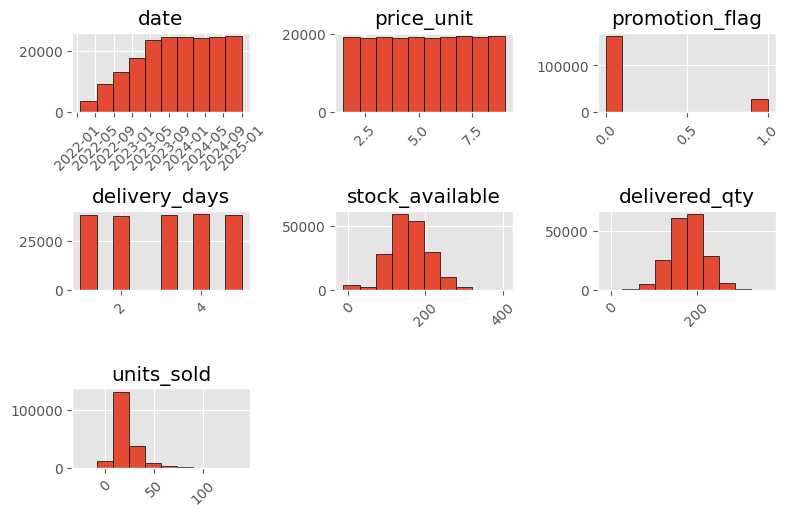

In [6]:
num_col = df.select_dtypes(exclude=['str']).columns

n_col = 3
n_row = len(num_col) 
plt.figure(figsize= (8,12))
for count, col in enumerate(num_col):
    plt.subplot(n_row, n_col, count + 1)
    df[col].hist(edgecolor = 'black')
    plt.title(col)
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

There number of outliers seems to be small, so we will just remove them

In [7]:
cols_to_check = ['units_sold', 'stock_available', 'delivered_qty']

initial_count = len(df)
df = df[(df[cols_to_check] >= 0).all(axis=1)]
final_count = len(df)

print(f"Removed {initial_count - final_count} rows containing negative values.")

Removed 3 rows containing negative values.


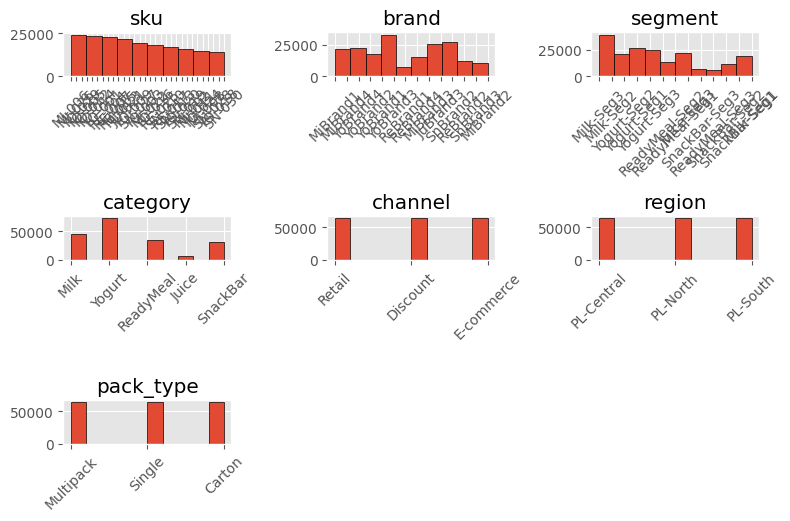

In [8]:
cat_col = df.select_dtypes(include=['str']).columns

n_col = 3
n_row = len(cat_col)

plt.figure(figsize= (8 ,12))
for count, col in enumerate(cat_col):
    plt.subplot(n_row, n_col, count + 1)
    df[col].hist(edgecolor = 'black')
    plt.title(col)
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()
    

`Brand` and `segment` has a lot of distinct features, so we will need to take special care of them, the rest can be *one-hot encoded* due to their low cardinal

In [9]:
cat = ['brand', 'segment']

for ele in cat:
    print(ele)
    print(df[ele].unique())
    print('-' * 50 + '\n')

brand
<ArrowStringArray>
['MiBrand1', 'MiBrand4', 'YoBrand4', 'YoBrand2', 'YoBrand1', 'YoBrand3',
 'ReBrand1', 'ReBrand4', 'MiBrand3', 'JuBrand3', 'SnBrand2', 'ReBrand2',
 'SnBrand3', 'MiBrand2']
Length: 14, dtype: str
--------------------------------------------------

segment
<ArrowStringArray>
[     'Milk-Seg3',      'Milk-Seg2',    'Yogurt-Seg2',    'Yogurt-Seg1',
    'Yogurt-Seg3', 'ReadyMeal-Seg2', 'ReadyMeal-Seg1',     'Juice-Seg3',
  'SnackBar-Seg3', 'ReadyMeal-Seg3',  'SnackBar-Seg2',  'SnackBar-Seg1',
      'Milk-Seg1']
Length: 13, dtype: str
--------------------------------------------------



Let's try get the `tier` as a feature, maybe different tier has different quality

In [10]:
df['segment_tier'] = df['segment'].str[-1].astype(int)

We are planning to Encode the top 5 and the rest can be merged into the 6th group, but let's check the proportion of each brand

In [11]:
# Check volume concentration
brand_shares = df.groupby('brand')['units_sold'].sum().sort_values(ascending=False)
brand_shares_pct = (brand_shares / brand_shares.sum()) * 100
print(brand_shares_pct)

brand
SnBrand2    14.314817
YoBrand4    12.418326
YoBrand3    10.565600
YoBrand2    10.144505
MiBrand3     8.358913
YoBrand1     8.098930
ReBrand4     7.664677
ReBrand2     6.264336
MiBrand1     5.717290
MiBrand4     4.008674
ReBrand1     3.935908
JuBrand3     3.272463
SnBrand3     2.721416
MiBrand2     2.514145
Name: units_sold, dtype: float64


Hmm the share are quite balanced, so we won't do that, instead, we are just going to one hot encode them later

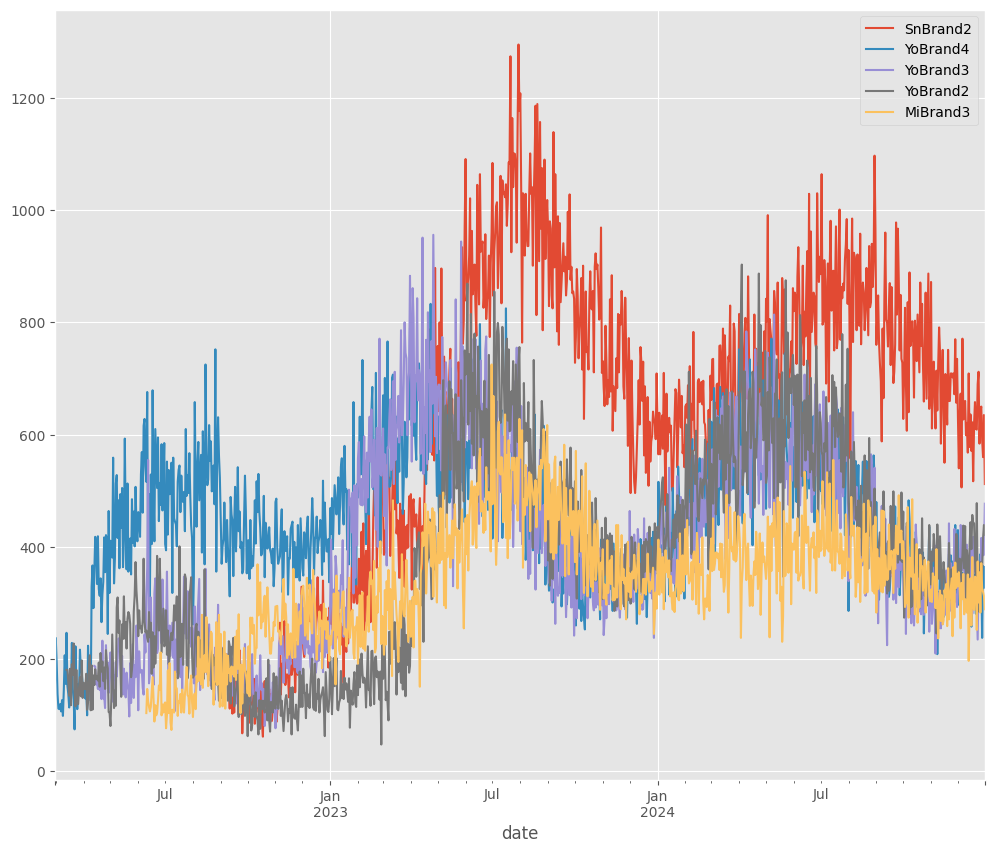

In [12]:
plt.figure(figsize = (12, 10))

top_5 = brand_shares.head(5).index

for b in top_5:
    brand_data = df[df['brand'] == b].groupby('date')['units_sold'].sum()
    brand_data.plot(label=b)
plt.legend()
plt.show()

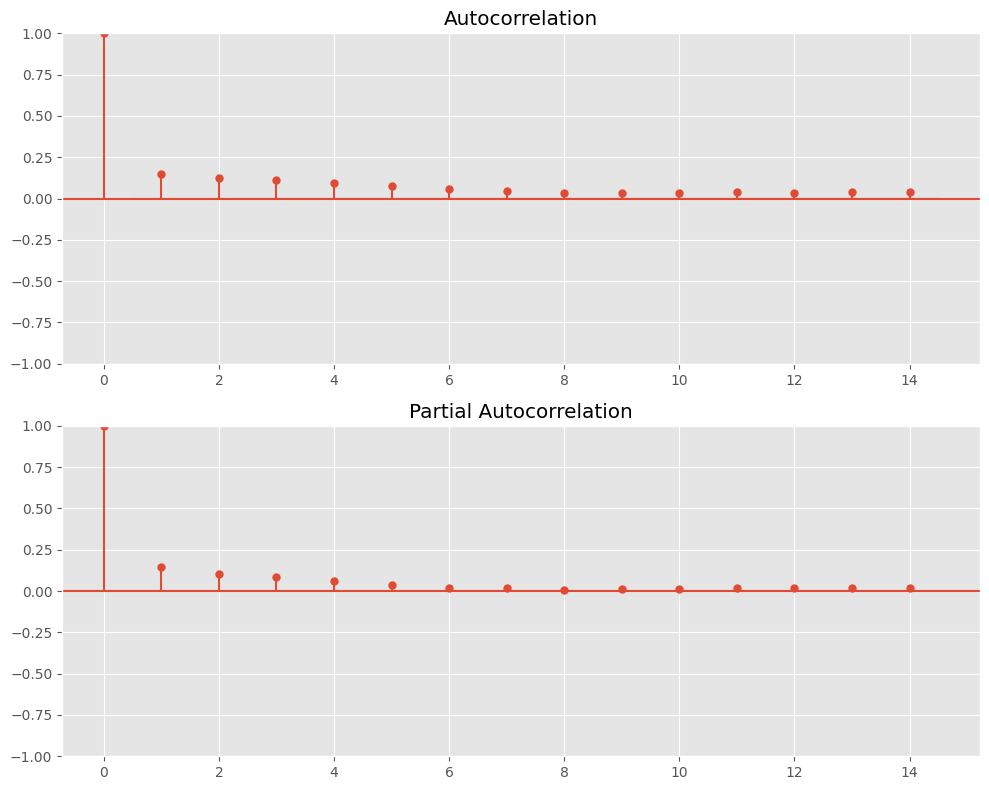

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df['units_sold']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(series, lags=14, ax=ax1) 
plot_pacf(series, lags=14, ax=ax2, method='ywm')

plt.tight_layout()
plt.show()

We are thinking of using the shifted value to help, but it doesn't look promising at all. But let's try it to see if it would helps.

We will make `day` and `month` feature and *cylindrical encode* them with **sin** and **cos**

We are also creating lag feature, only for `units_sold` tho. We assume that other features (`promotion_flag`, `stock_available`, `delivered_qty` - could be the same as *ordered quantity*)



In [14]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

df['day_sin'] = np.sin(2 * np.pi * (df['day_of_week'] / 7))
df['day_cos'] = np.cos(2 * np.pi * (df['day_of_week'] / 7))

df['month_sin'] = np.sin(2 * np.pi * (df['month'] / 12))
df['month_cos'] = np.cos(2 * np.pi * (df['month'] / 12))


group_keys = ['sku', 'region', 'channel', 'segment'] 
df = df.sort_values(by=group_keys + ['date'])

df['units_sold_lag1'] = df.groupby(group_keys)['units_sold'].shift(1)
df['units_sold_lag7'] = df.groupby(group_keys)['units_sold'].shift(7)

df = df.dropna()

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 188864 entries, 9543 to 190519
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             188864 non-null  datetime64[us]
 1   sku              188864 non-null  str           
 2   brand            188864 non-null  str           
 3   segment          188864 non-null  str           
 4   category         188864 non-null  str           
 5   channel          188864 non-null  str           
 6   region           188864 non-null  str           
 7   pack_type        188864 non-null  str           
 8   price_unit       188864 non-null  float64       
 9   promotion_flag   188864 non-null  int64         
 10  delivery_days    188864 non-null  int64         
 11  stock_available  188864 non-null  int64         
 12  delivered_qty    188864 non-null  int64         
 13  units_sold       188864 non-null  int64         
 14  segment_tier     188864 non-null 

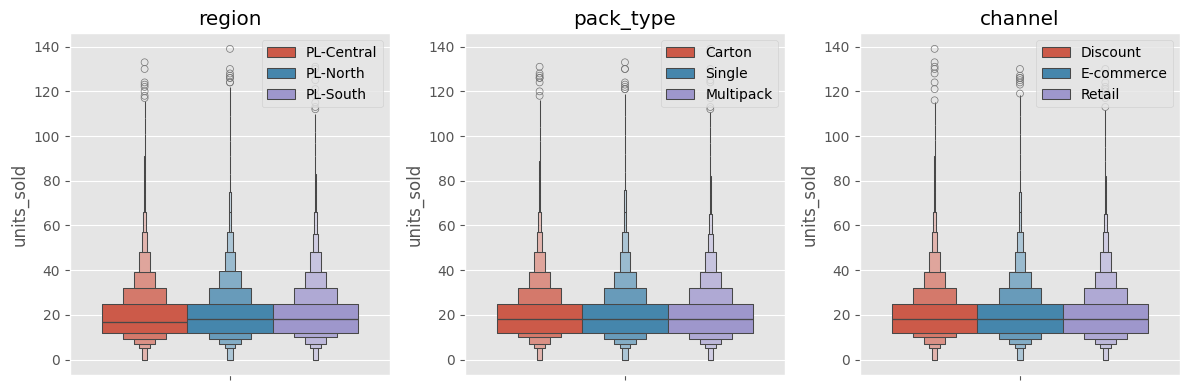

In [16]:
hue_feat = ['region', 'pack_type', 'channel']

plt.figure(figsize= (12,4))

for count, ele in enumerate(hue_feat):
    plt.subplot(1, 3, count + 1)
    sns.boxenplot(df, y = 'units_sold', hue = ele)
    plt.legend(loc = 'upper right')
    plt.title(ele)


plt.tight_layout()
plt.show()

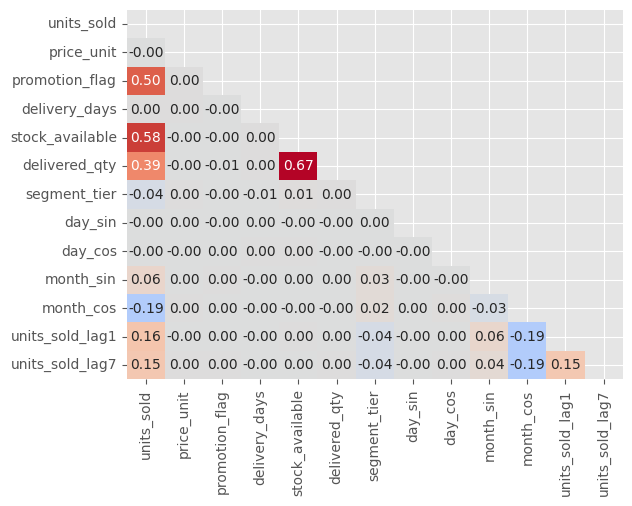

In [17]:
feature_corr = ['price_unit', 'promotion_flag', 'delivery_days', 
                'stock_available', 'delivered_qty',
                'segment_tier', 'day_sin', 'day_cos',
                'month_sin' , 'month_cos',
                'units_sold_lag1', 'units_sold_lag7']

target = ['units_sold']


matrix = df[target + feature_corr].corr()

mask = np.triu(np.ones_like(matrix, dtype = bool))

sns.heatmap(matrix, mask = mask, center = 0, cmap = 'coolwarm', cbar = False,
            annot = True, fmt = '.2f')

plt.show()

A lot of features doesn't so correlation at all, but we will still include them at first, and then slowly remove the bad one using the validation set

We split our data into 3 section: **train - val - test** (70 - 15 -15)

**Train** and **val** set will be used to train and finetune our models, and to figure out what features would be best for our case

In [18]:
df = df.sort_values('date').reset_index(drop=True)

# 70 - 15 - 15 split for train val test
train_idx = int(len(df) * 0.70)
val_idx = int(len(df) * 0.85)

train_df = df.iloc[:train_idx]
val_df   = df.iloc[train_idx:val_idx]
test_df  = df.iloc[val_idx:]

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")

Train: 132204 rows | Val: 28330 rows | Test: 28330 rows


In [19]:
df.columns

Index(['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region',
       'pack_type', 'price_unit', 'promotion_flag', 'delivery_days',
       'stock_available', 'delivered_qty', 'units_sold', 'segment_tier',
       'day_of_week', 'month', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'units_sold_lag1', 'units_sold_lag7'],
      dtype='str')

In [20]:
# feature are commented out during finetuning to get the best results

col_for_X = [
    # 'region', 'pack_type', 'channel', 
    'category',
    # 'brand',

    # 'price_unit', 
    'promotion_flag', 
    # 'delivery_days', 
    'stock_available', 'delivered_qty',
    'segment_tier', 
    
    # 'day_sin', 'day_cos',
    'month_sin' , 'month_cos',
    'units_sold_lag1', 'units_sold_lag7',
]

target = ['units_sold']

X_train, y_train = train_df[col_for_X], train_df[target]
X_val, y_val = val_df[col_for_X], val_df[target]
X_test, y_test = test_df[col_for_X], test_df[target]

We are gonna use `ColumnTransformer` to help setting up the `preprocessor` for *one-hot encoder*, and wrapping our models in `Pipeline` as well for clean and concise code

We are using `XGBoost`, `LGBM`, `CatBoost` - which are all tree models. They are the best for tabular data for this case

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Define feature groups
one_hot_cols = ['category', 
                # 'brand',
                # 'channel', 'region', 
                # 'pack_type'
                ]

preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_cols)
    ],
    remainder='passthrough' 
)

# Make pipeline
models = {
    'xgb' : Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, early_stopping_rounds=50))
]),


    'lgbm' : Pipeline([
    ('prep', preprocessor),
    ('model', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05))
]),

    'catboost' : Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostRegressor(iterations=500, learning_rate=0.05, verbose=0,
    allow_writing_files=False))
])
}

We also have to fit the `preprocessor` early to transform the **val** set

In [22]:
preprocessor.set_output(transform="pandas")
preprocessor.fit(X_train, y_train)
X_val_transformed = preprocessor.transform(X_val)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}
trained_pipelines = {}

for name, pipe in models.items():
    print(f"--- Training {name.upper()} ---")
    
    if name == 'xgb':
        # XGBoost needs the eval_set to use early_stopping_rounds
        pipe.named_steps['model'].fit(
            preprocessor.transform(X_train), y_train,
            eval_set=[(X_val_transformed, y_val)],
            verbose=False
        )
    elif name == 'lgbm':
        # LightGBM training
        pipe.fit(X_train, y_train.values.ravel())
    else:
        # CatBoost training
        pipe.fit(X_train, y_train.values.ravel())
    
    y_pred = pipe.predict(X_val)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    trained_pipelines[name] = pipe



--- Training XGB ---
--- Training LGBM ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 132204, number of used features: 13
[LightGBM] [Info] Start training from score 20.472618
--- Training CATBOOST ---


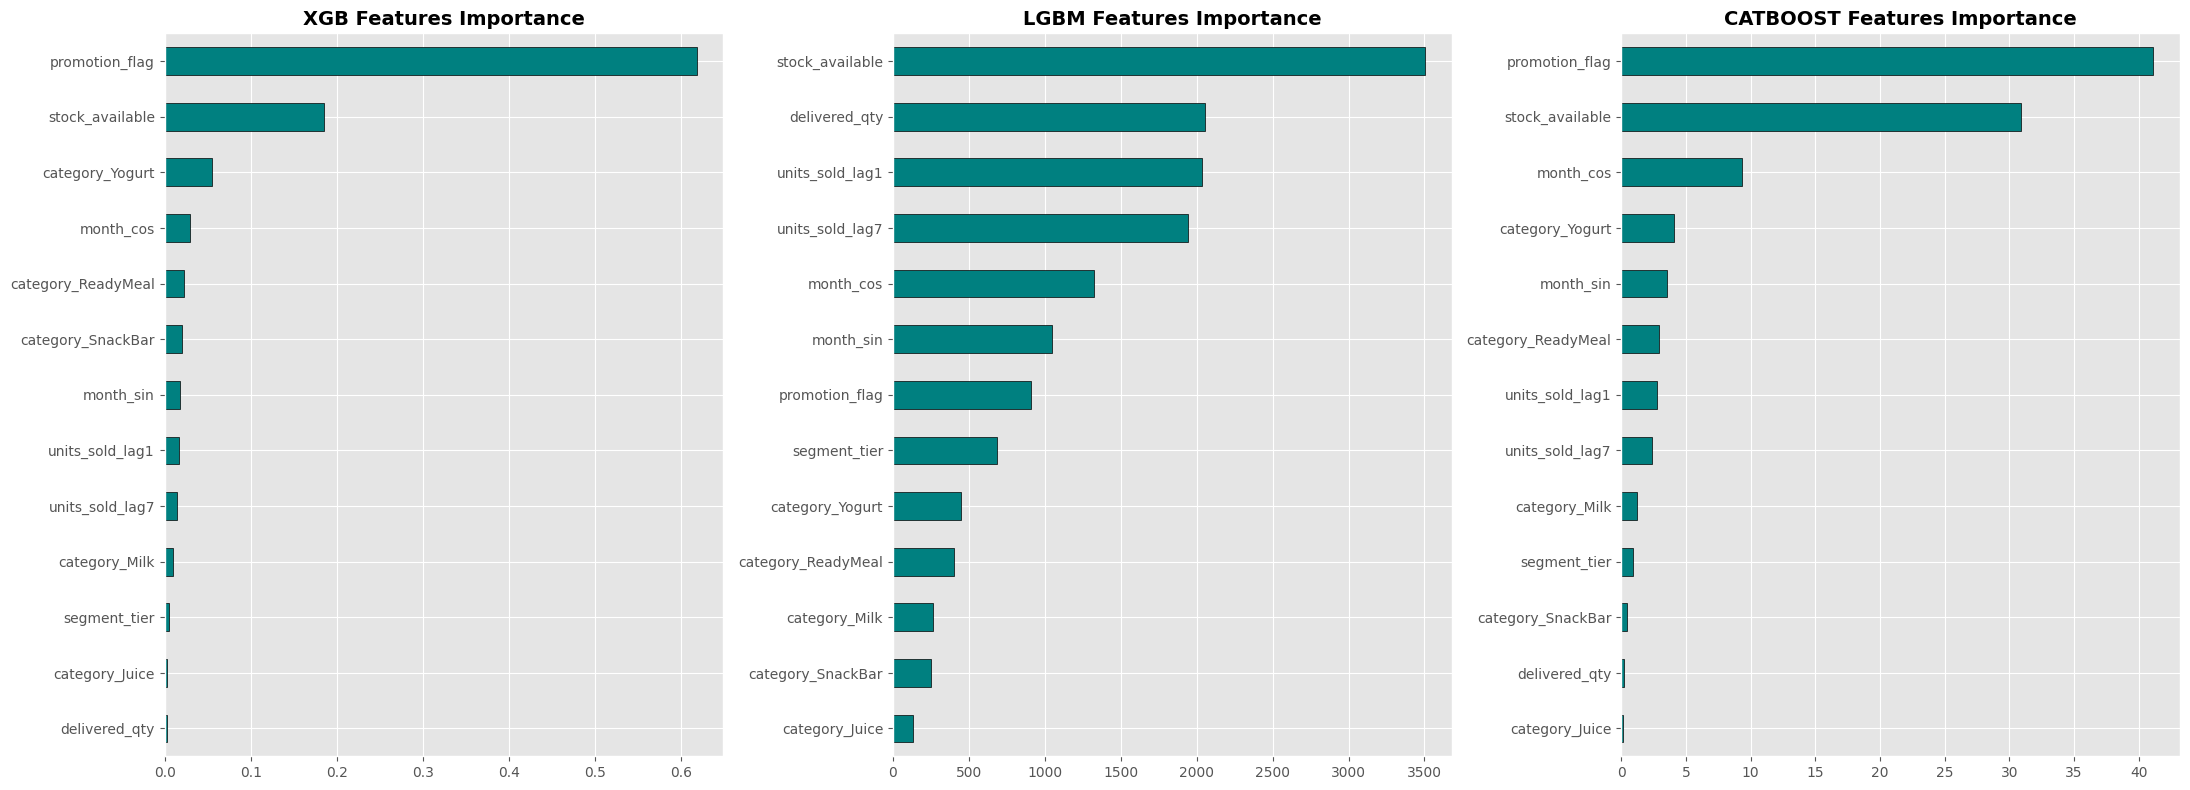

In [24]:
ohe_feature_names = list(models['xgb'].named_steps['prep'].transformers_[0][1].get_feature_names_out())

passthrough_cols = [col for col in col_for_X if col not in one_hot_cols]

all_features = ohe_feature_names + passthrough_cols

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharex=False)

for i, (name, pipe) in enumerate(models.items()):
    importance = pipe.named_steps['model'].feature_importances_
    
    feat_imp = pd.Series(importance, index=all_features).sort_values(ascending=True)
    
    feat_imp.plot(kind='barh', ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'{name.upper()} Features Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
leaderboard = pd.DataFrame(results).T.sort_values('RMSE')
print("\nFinal Results on Val Set:")
leaderboard


Final Results on Val Set:


,MAE,RMSE,R2
xgb,4.387433,5.999633,0.742591
catboost,4.502449,6.217565,0.723551
lgbm,4.522447,6.275024,0.718418


We used this validation metrics and the feature importances to finetune our model to get the best results

All of the models perform quite well, and quite the same after finetuned, with `xgb` getting a bit better.

For the next step, we will make a `VotingRegressor` - combination of our 3 models, and test the results of this model along with the 3 standalone models to compare their results

In [26]:
results = {}
trained_pipelines = {}

for name, pipe in models.items():
    
    y_pred = pipe.predict(X_test)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    trained_pipelines[name] = pipe


In [27]:
from sklearn.ensemble import VotingRegressor

# Redefine XGBoost without early_stopping for the ensemble
xgb_clean = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=500, learning_rate=0.05)) # Removed early_stopping
])

vr = VotingRegressor(
    estimators=[
        ('xgb', xgb_clean),
        ('lgbm', models['lgbm']),
        ('cat', models['catboost'])
    ],
    weights=[0.36, 0.30, 0.34]
)

print("Training Voting Regressor...")
vr.fit(X_train, y_train)
print("Training Complete!")

Training Voting Regressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 132204, number of used features: 13
[LightGBM] [Info] Start training from score 20.472618
Training Complete!


In [28]:
y_pred_vr = vr.predict(X_test)

vr_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred_vr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_vr)),
    'R2': r2_score(y_test, y_pred_vr)
}

pd.Series(vr_metrics)

MAE     3.375586
RMSE    4.680308
R2      0.743133
dtype: float64

In [29]:
leaderboard = pd.DataFrame(results).T.sort_values('RMSE')
print("\nFinal Results on Test Set:")
leaderboard


Final Results on Test Set:


,MAE,RMSE,R2
catboost,3.372394,4.678167,0.743368
lgbm,3.387942,4.693471,0.741686
xgb,3.723232,4.959023,0.711629


The models actually perform better than the **validation** set. And the `votingRegressor` also share the best performance with `catboost`. And `xgb` has been going from the best to the worst performing model

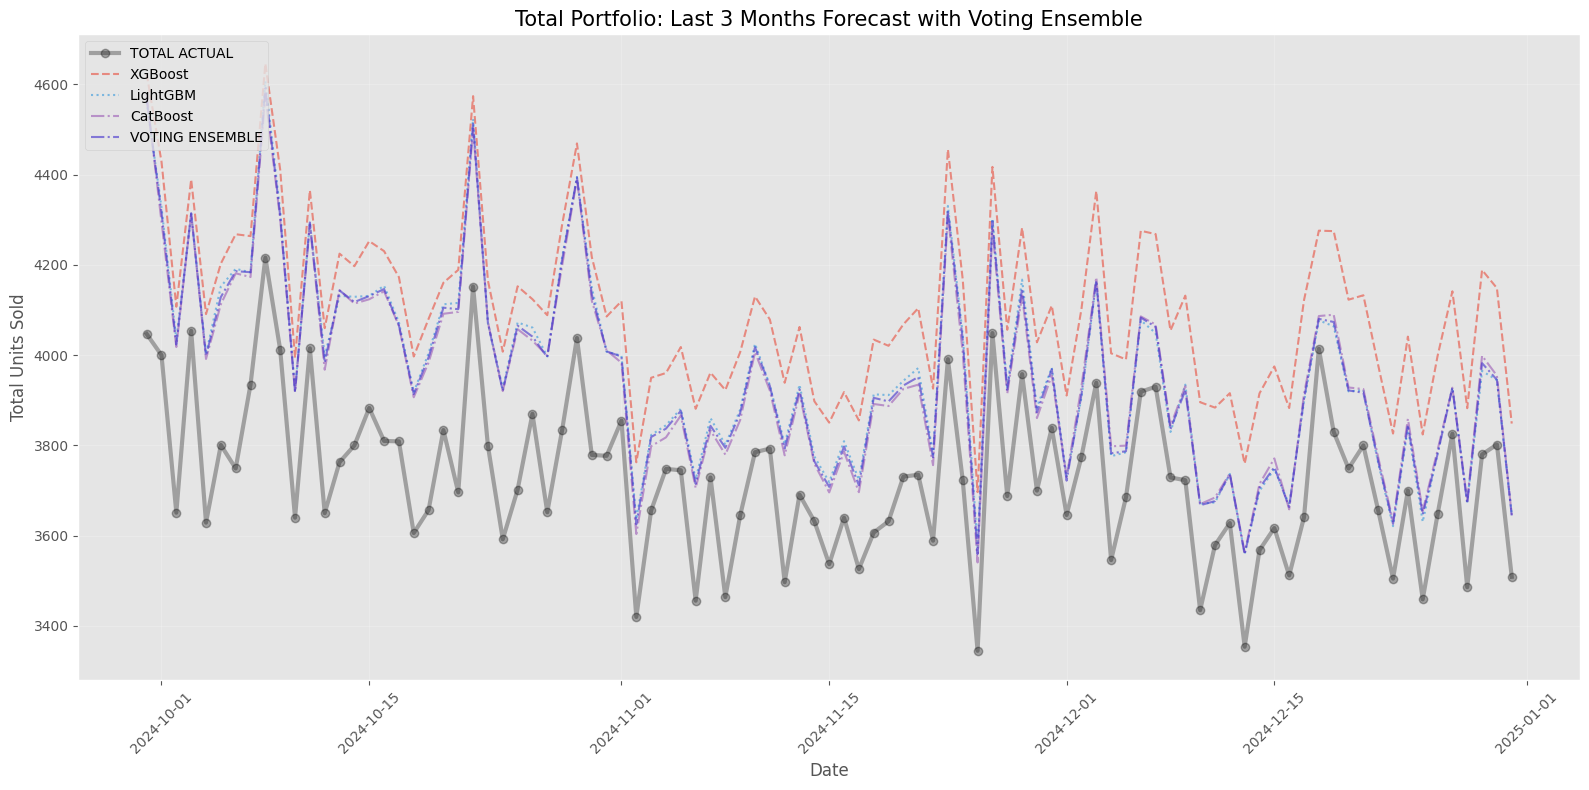

In [30]:
comp_df = pd.DataFrame({
    'date': pd.to_datetime(test_df['date'].values),
    'actual': y_test.values.flatten(),
    'xgb': models['xgb'].predict(X_test).flatten(),
    'lgbm': models['lgbm'].predict(X_test).flatten(),
    'catboost': models['catboost'].predict(X_test).flatten(),
    'voting_ensemble': vr.predict(X_test).flatten() 
})


max_date = comp_df['date'].max()
cutoff_date = max_date - pd.DateOffset(months=3)
last_3m_df = comp_df[comp_df['date'] >= cutoff_date]


daily_3m = last_3m_df.groupby('date').sum().reset_index()


plt.figure(figsize=(16, 8))

# Actuals
plt.plot(daily_3m['date'], daily_3m['actual'], 
         label='TOTAL ACTUAL', color='black', linewidth=3, alpha=0.3, marker='o')

# Individual Models 
plt.plot(daily_3m['date'], daily_3m['xgb'], label='XGBoost', color='#e74c3c', linestyle='--', alpha=0.6)
plt.plot(daily_3m['date'], daily_3m['lgbm'], label='LightGBM', color='#3498db', linestyle=':', alpha=0.6)
plt.plot(daily_3m['date'], daily_3m['catboost'], label='CatBoost', color='#9b59b6', linestyle='-.', alpha=0.6)
plt.plot(daily_3m['date'], daily_3m['voting_ensemble'], 
         label='VOTING ENSEMBLE', color="#402ecc", linestyle='-.', alpha=0.6)

plt.title(f"Total Portfolio: Last 3 Months Forecast with Voting Ensemble", fontsize=15)
plt.ylabel("Total Units Sold")
plt.xlabel("Date")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

You can see that the prediction of `CatBoost` and `Voting Ensemble` are basically overlapping, their predictions are almost the same. So if we are to move on to production, we would likely to pick `CatBoost` as the best performing model. `Voting Ensemble` might just be overkill

Also due to the high number of different items, we use the sum of the `units_sold` to plot, so the errors add up.

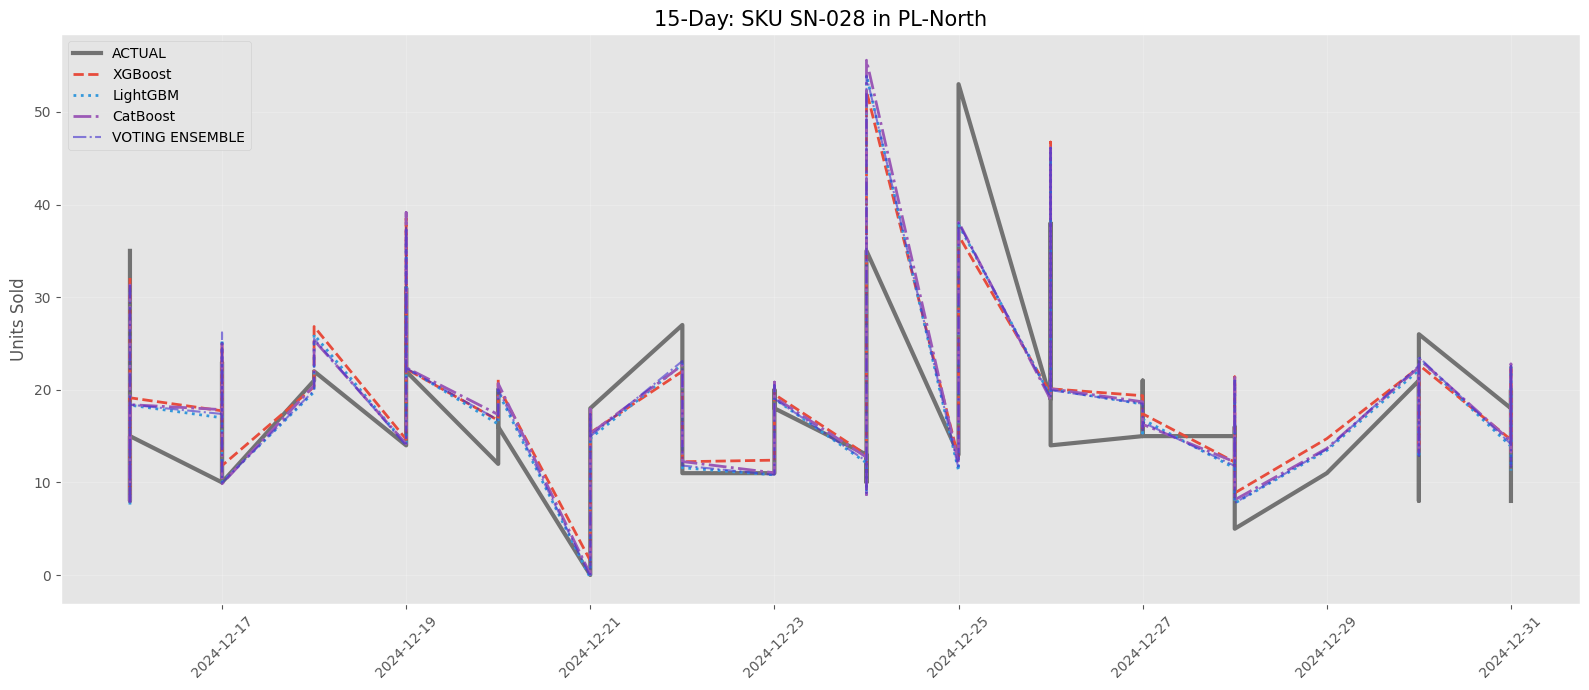

In [31]:
target_sku, target_region = test_df.groupby(['sku', 'region'])['units_sold'].sum().idxmax()

# get a specific item
item_mask = (test_df['sku'].values == target_sku) & \
            (test_df['region'].values == target_region)

item_plot_df = comp_df[item_mask].copy()
item_plot_df['date'] = pd.to_datetime(item_plot_df['date'])

# Filter for the last 15 days
max_date = item_plot_df['date'].max()
cutoff_15d = max_date - pd.Timedelta(days=15)
item_plot_df = item_plot_df[item_plot_df['date'] >= cutoff_15d].sort_values('date')


# Plot
plt.figure(figsize=(16, 7))

plt.plot(item_plot_df['date'], item_plot_df['actual'], label='ACTUAL', color='black', linewidth=3, alpha=0.5)
plt.plot(item_plot_df['date'], item_plot_df['xgb'], label='XGBoost', color='#e74c3c', ls='--', linewidth=2)
plt.plot(item_plot_df['date'], item_plot_df['lgbm'], label='LightGBM', color='#3498db', ls=':', linewidth=2)
plt.plot(item_plot_df['date'], item_plot_df['catboost'], label='CatBoost', color='#9b59b6', ls='-.', linewidth=2)
plt.plot(item_plot_df['date'], item_plot_df['voting_ensemble'], 
         label='VOTING ENSEMBLE', color="#402ecc", linestyle='-.', alpha=0.6)


plt.title(f"15-Day: SKU {target_sku} in {target_region}", fontsize=15)
plt.ylabel("Units Sold")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()